In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [6]:
df = sns.load_dataset('brain_networks').bfill()
df.head(2)

,network,1,1.1,2,2.1,3,3.1,4,4.1,5,...,16.5,16.6,16.7,17,17.1,17.2,17.3,17.4,17.5,17.6
0,node,1,1,1,1,1,1,1,1,1,...,3,4,4,1,1,2,2,3,3,4
1,hemi,lh,rh,lh,rh,lh,rh,lh,rh,lh,...,rh,lh,rh,lh,rh,lh,rh,lh,rh,lh


In [7]:
df.isnull().sum()

network    0
1          0
1.1        0
2          0
2.1        0
          ..
17.2       0
17.3       0
17.4       0
17.5       0
17.6       0
Length: 63, dtype: int64

In [8]:
df.network.unique()

<ArrowStringArray>
['node', 'hemi',    '0',    '1',    '2',    '3',    '4',    '5',    '6',
    '7',
 ...
  '910',  '911',  '912',  '913',  '914',  '915',  '916',  '917',  '918',
  '919']
Length: 922, dtype: str

In [9]:
df.shape

(923, 63)

In [13]:
from sklearn.preprocessing import StandardScaler
x = df.iloc[2:].drop(columns=['network']).astype(float)
y = df['network'].iloc[2:]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [16]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=4)
label = kmean.fit_predict(x_scaled)

C:\Users\dell\AppData\Local\Temp\ipykernel_18064\3817322070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label, palette='viridis')


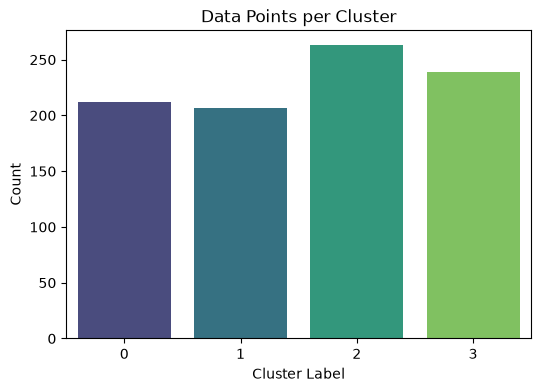

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x=label, palette='viridis')
plt.title('Data Points per Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

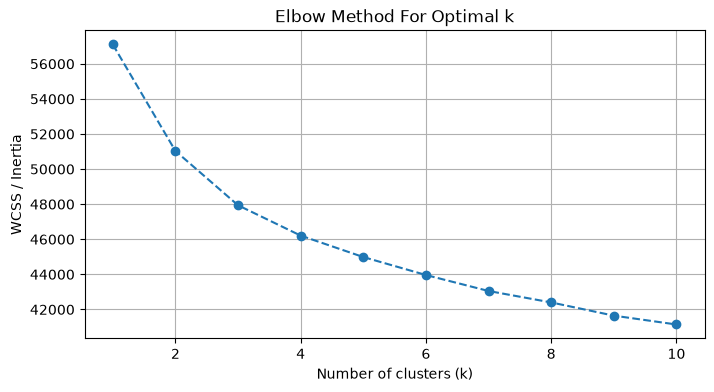

In [18]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
x_pca

array([[ 1.66433739,  0.78446274],
       [ 1.66433739,  0.78446274],
       [ 2.32692555, -1.0053949 ],
       ...,
       [ 4.7204897 ,  2.22408181],
       [ 4.94766025,  1.32065581],
       [ 2.67940071, -1.45186   ]], shape=(921, 2))

In [21]:
df_pca = pd.DataFrame(x_pca,columns=['pca1','pca2'])
df_pca.head(4)

,pca1,pca2
0,1.664337,0.784463
1,1.664337,0.784463
2,2.326926,-1.005395
3,0.300784,-2.715563


In [22]:
df_pca['pca_cluster'] = kmean.fit_predict(df_pca)
df_pca.head()

,pca1,pca2,pca_cluster
0,1.664337,0.784463,3
1,1.664337,0.784463,3
2,2.326926,-1.005395,0
3,0.300784,-2.715563,0
4,0.329631,-3.562135,0


<Axes: xlabel='pca1', ylabel='pca2'>

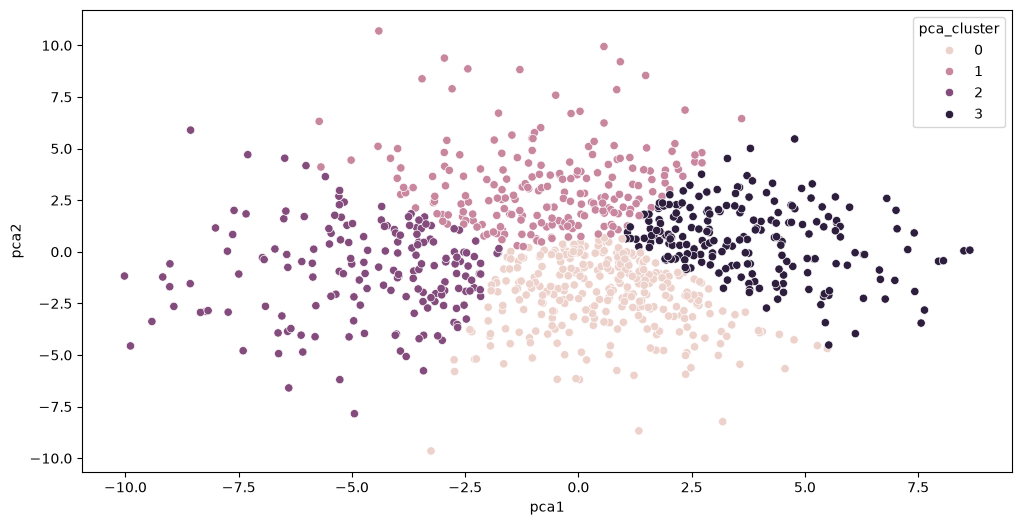

In [25]:
plt.figure(figsize=(12,6))
sns.scatterplot(x= 'pca1',y= 'pca2',data= df_pca,hue='pca_cluster')